In [1]:
from src import *
from src.modelling import *


### load grid data & engineered features

In [2]:
sdo = setDisplayOptions()
r_generator, r_worker = setReproducibility(seed=17711)
# ---
root = Path("./data/")
imgs = Path("./imgs.bak/")
imgs.mkdir(exist_ok=True)


In [3]:
schema = yamlLoader("./schema/modelling.yaml")
data = gpd.read_file(f"{root}/tcbGridFeatures-TSAE29.gpkg")
f_outputs = schema["targets"]
# ---
printFeatureCardinality(data)


data.shape=(19474, 32) ... 0.00GB
[int] id                 : 19474   [int] isBikeStation      : 2       [int] nHousing           : 173  
[int] nJob               : 312     [float] popTotal         : 3536    [float] avgIncome        : 1208 
[int] nRetail            : 11      [int] nOffice            : 4       [int] nSchool            : 6    
[float] distCBD          : 19345   [float] distRetail       : 17236   [float] distOffice       : 18726
[float] distSchool       : 18406   [float] Slope            : 1871    [float] Elevation        : 14379
[int] nStreet            : 52      [int] nJunction          : 16      [int] nMotorLane         : 828  
[int] nBikeLane          : 1044    [float] cyclingFlow      : 637     [int] peopleFlow         : 1528 
[int] nBusStop           : 13      [int] nBusLine           : 24      [float] distBusStop      : 17440
[float] transitFlow      : 1961    [float] cyclingFlow.mean : 1974    [float] cyclingFlow.max  : 378  
[float] peopleFlow.mean  : 7612    [flo

### sanity check feature correlations

In [4]:
to = tabularDataloader(data, f_outputs=f_outputs, normalised=True, pct_valid=0.0, verbose=False)
X, y = to.train.xs, to.train.ys
print(f"{X.shape=}, {y.shape=}")
print(f"{to.x_names=}")


to.train (X,y): (19474, 29) (19474, 2)
to.valid (X,y): (0, 29) (0, 2)
X.shape=(19474, 29), y.shape=(19474, 2)
to.x_names=['nHousing', 'nJob', 'popTotal', 'avgIncome', 'nRetail', 'nOffice', 'nSchool', 'distCBD', 'distRetail', 'distOffice', 'distSchool', 'Slope', 'Elevation', 'nStreet', 'nJunction', 'nMotorLane', 'nBikeLane', 'cyclingFlow', 'peopleFlow', 'nBusStop', 'nBusLine', 'distBusStop', 'transitFlow', 'cyclingFlow.mean', 'cyclingFlow.max', 'peopleFlow.mean', 'peopleFlow.max', 'transitFlow.mean', 'transitFlow.max']


In [5]:
# fn = f"{imgs}/FeatureClusters.png"
# featureClustering(X, figsize=(9, 7), font_size=11, save=None)


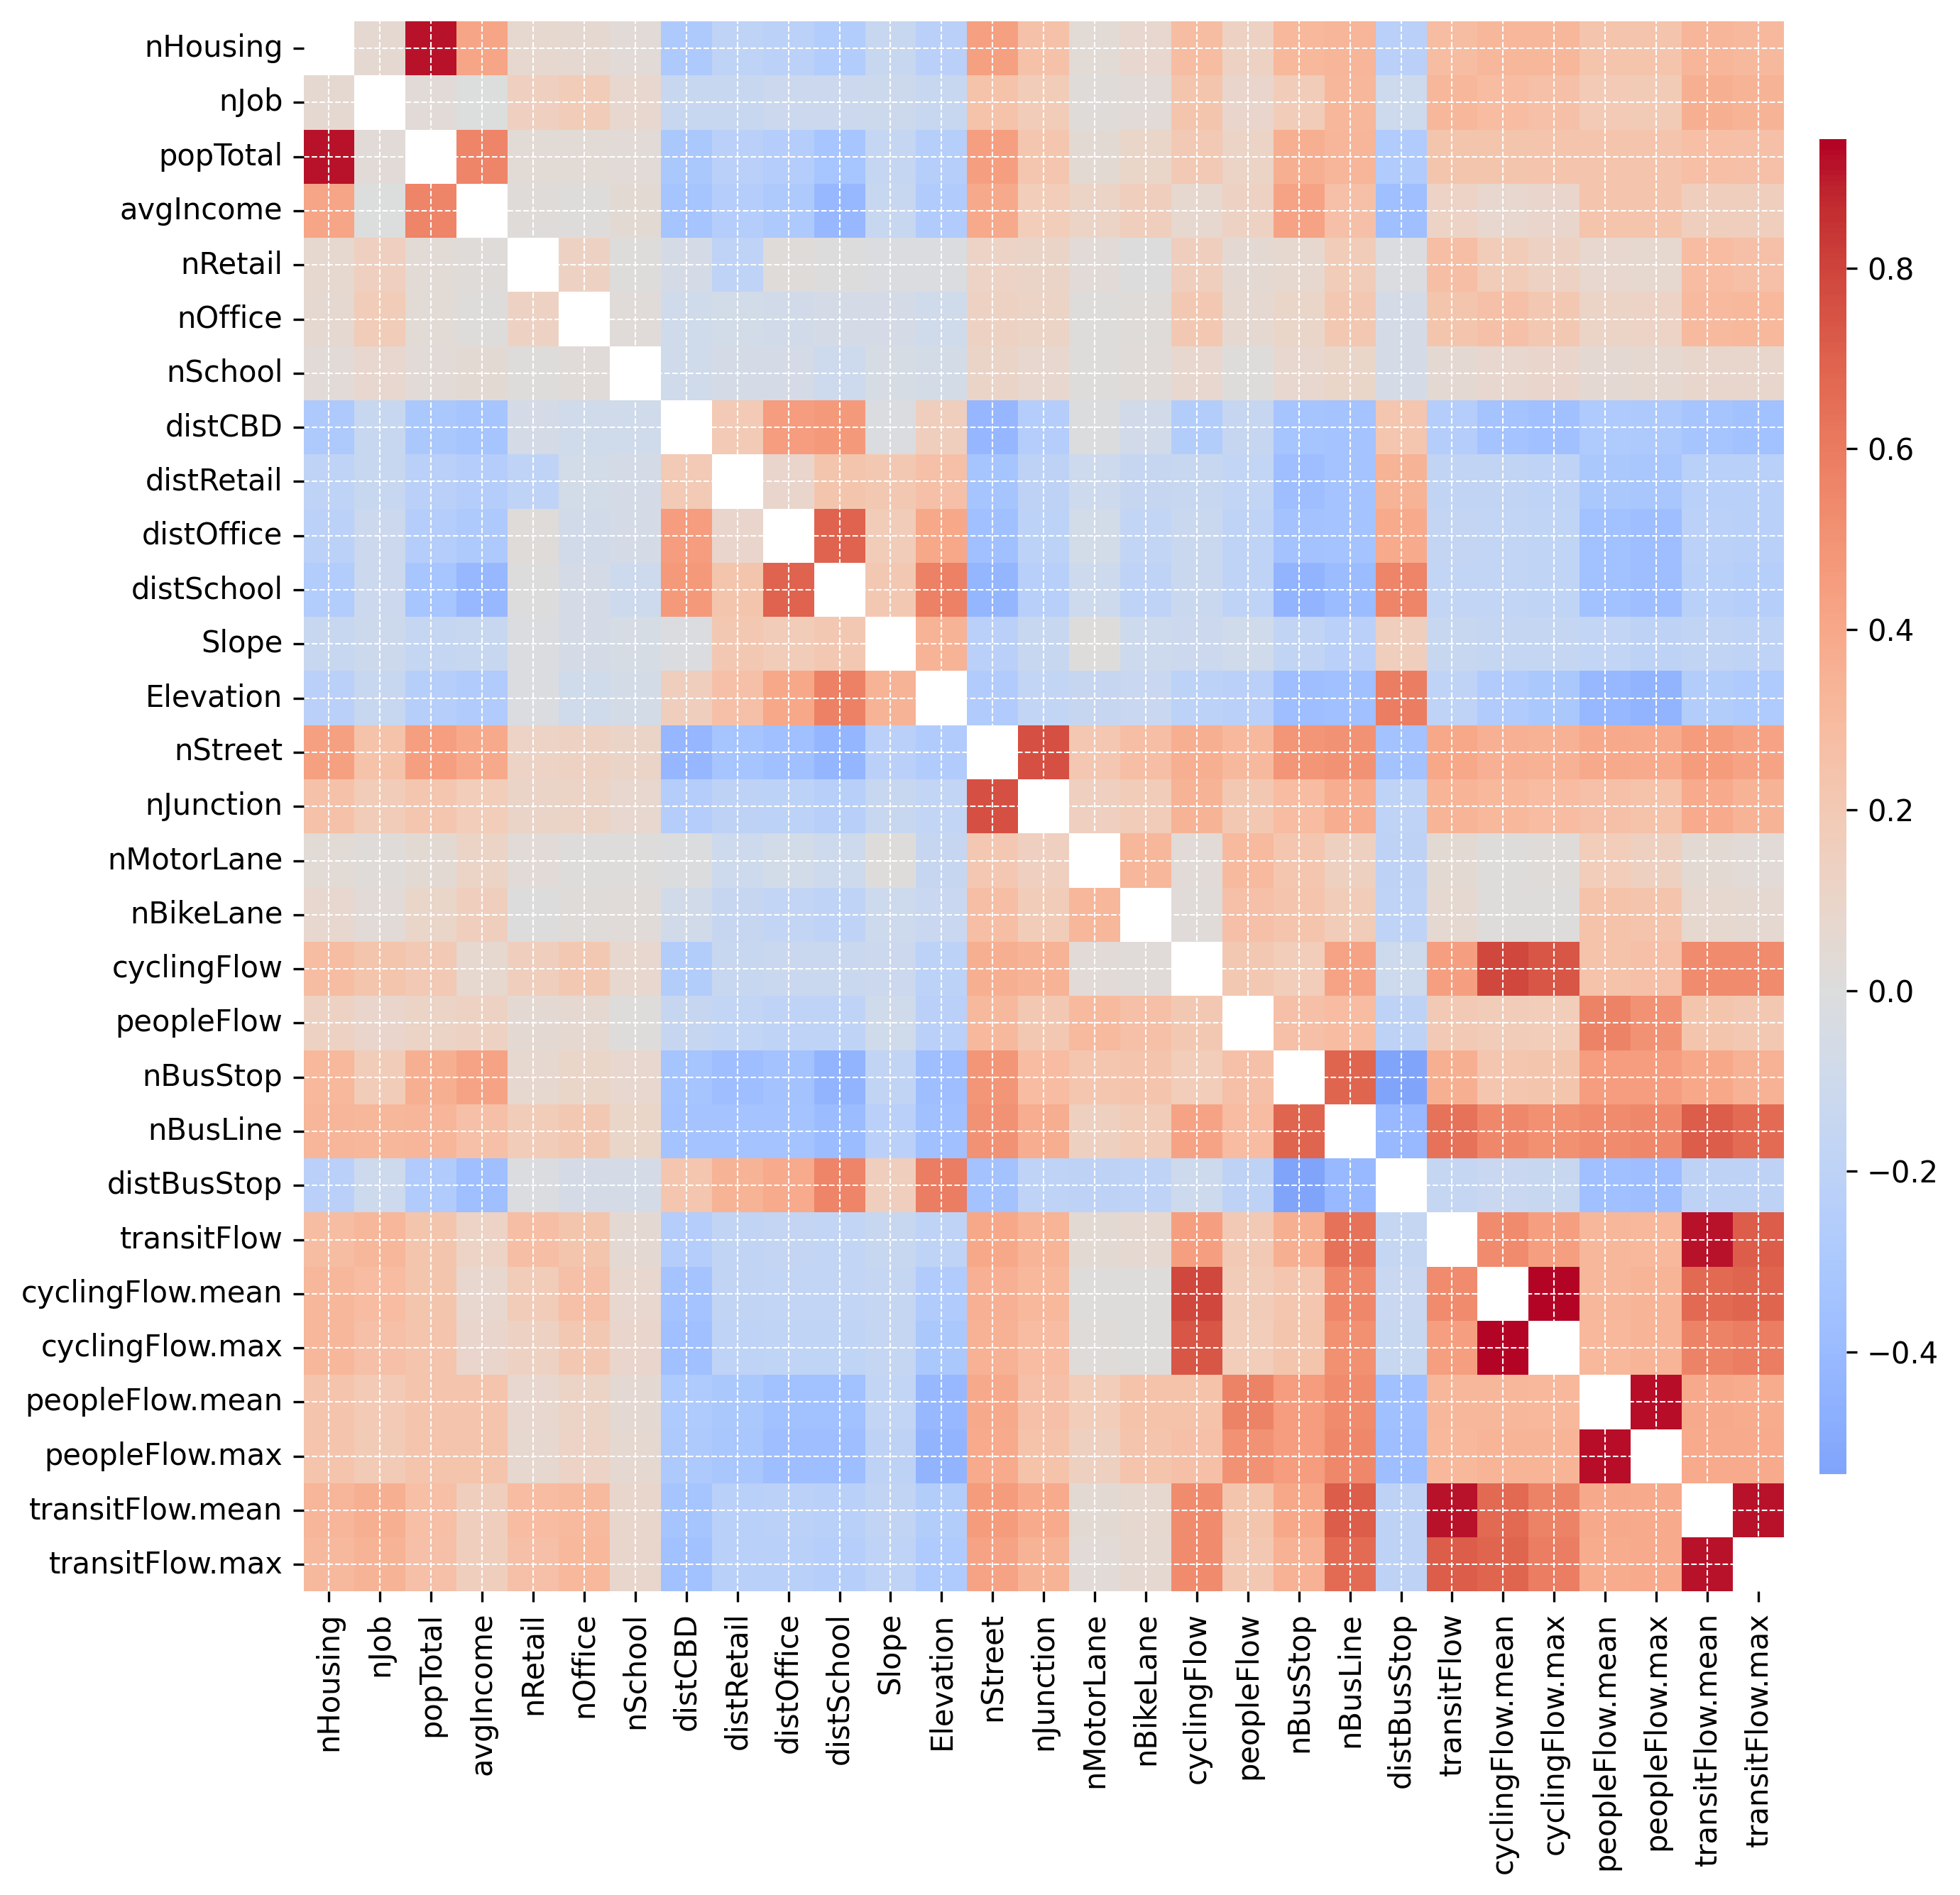

In [6]:
df = X.corr().round(4)
df.values[np.arange(df.shape[0]), np.arange(df.shape[0])] = np.nan  # remove self-correlations

plt.figure(figsize=(10, 9), dpi=300)
sns.heatmap(
    df,
    annot=False,
    cmap="coolwarm",
    center=0,
    annot_kws={"fontsize": 9},
    cbar_kws={"shrink": 0.85, "pad": 0.02, "aspect": 50},
)
plt.grid(which="major", color="white", linestyle="--", linewidth=0.5)
plt.tight_layout()
fn = f"{imgs}/FeatureCorrelationHeatmap.png"
plt.savefig(fn, bbox_inches="tight")
plt.show()


### plot heatmap of input features

In [7]:
def plotFeatureDistribution(gdf, features, log=False, n_cols=4, save: str | None = None):
    nf = len(features)
    n_cols = min(n_cols, nf)
    n_rows = int(np.ceil(nf / n_cols))

    if log:
        gdf = gdf.copy()
        for f in features:
            gdf[f] = logTransform(gdf[f])

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows), dpi=100)
    axes = axes.flatten()  # type:ignore
    for i, ax in enumerate(axes):
        if i < nf:  # set bounds
            ax.set_axis_off()
            ax.margins(0.01)  # remove whitespace
        else:
            ax.remove()  # remove unused axes

    border = gpd.GeoSeries(gdf.union_all(method="unary"), crs=data.crs)
    for idx, feature in enumerate(features):
        ax = axes[idx]
        f_card = gdf[feature].nunique()
        palette = slicePalette("RdBu", min_val=0.15, max_val=0.85, n=f_card, reverse=True)
        border.boundary.plot(ax=ax, color="black", linewidth=1.5)
        gdf.plot(column=feature, ax=ax, cmap=palette, markersize=8, legend=False)
        ax.text(
            0.87,
            0.02,
            feature,
            transform=ax.transAxes,
            fontsize=10,
            ha="right",
            va="bottom",
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.8),
        )

    plt.tight_layout(pad=0)
    plt.subplots_adjust(wspace=-0.27, hspace=0.05)
    if save:
        plt.savefig(save, bbox_inches="tight", dpi=300)
        plt.close()
    plt.show()


In [8]:
l_features = schema["FeatureDistributions"]
fn = f"{imgs}/FeatureDistributions.png"
plotFeatureDistribution(data, features=l_features, n_cols=4, log=True, save=fn)  # type:ignore


### cluster analysis with tabular features

In [9]:
aoiFeatures = list(to.x_names)  # type:ignore
r_fc = gridClusterAnalysis(to, aoiFeatures)
r_results = r_fc.runAnalysis(best_k=5)
r_gridClusters = r_fc.saveResults()


running feature clustering analysis...
using provided cluster size for computing k-means...
analysis complete. optimal clusters: 5 (silhouette: 0.135)


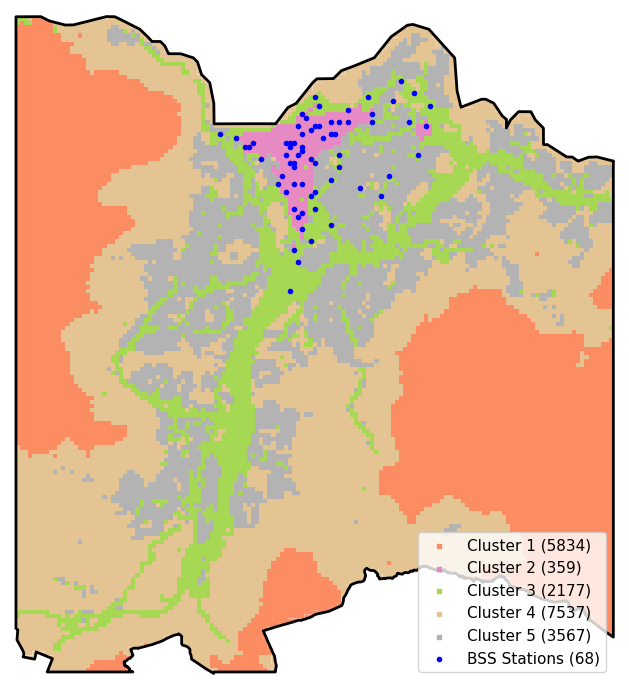

In [10]:
fn = f"{imgs}/ClusterAnalysisMap.raw.png"
m = staticMultiClusterMap(data, r_gridClusters, fn=fn)


### end